In [3]:
# What are the specific areas of interests in different countries

In [4]:
import pandas as pd
import numpy as np
import importlib

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

import utility_functions as uf

In [96]:
# importlib.reload(uf)

In [5]:
path = "data/"

df_country_subfield = pd.read_csv(path+"df_country_subfield.csv", index_col="country")

In [7]:
df_country_subfield_norm = (
    df_country_subfield
    .div(df_country_subfield.sum(axis=1), axis=0)
)

In [95]:
df_world_subfield = (
    df_country_subfield.sum(axis=0)
    .to_frame()
    .T
)

df_world_subfield_norm = (
    df_world_subfield
    .div(df_world_subfield.sum(axis=1), axis=0)
)
# df_world_subfield_norm

In [83]:
df_country_subfield_norm_world = (
    df_country_subfield_norm
    .div(df_world_subfield_norm.loc[0])
)

df_country_subfield_norm_world_log = (
    np.log(df_country_subfield_norm_world)
)

df_country_subfield_norm_world_norm = (
    df_country_subfield_norm_world
    .div(df_country_subfield_norm_world.sum(axis=1), axis=0)
)
# df_country_subfield_norm_world_log

In [12]:
# df_country_subfield_norm.to_csv(path+"df_country_subfield_norm.csv")
df_country_subfield_norm_world.to_csv(path+"df_country_subfield_norm_world.csv")
df_country_subfield_norm_world_log.to_csv(path+"df_country_subfield_norm_world_log.csv")
# df_country_subfield_norm_world_norm.to_csv(path+"df_country_subfield_norm_world_norm.csv")

In [13]:
df_plot = pd.concat([
    df_country_subfield_norm.loc[country],
    df_world_subfield_norm.loc[0],
    # df_country_subfield_norm_world.loc[country],
    df_country_subfield_norm_world_norm.loc[country]
], axis=1)
df_plot.columns = ["share_norm", "share_norm_world", "representation_norm"]
# df_plot

In [14]:
x = df_country_subfield_norm.columns.to_list()

y1 = df_country_subfield_norm.loc[country]          # left axis
y2 = df_world_subfield_norm.loc[0]      # left axis
y3 = df_country_subfield_norm_world_log.loc[country]    # right axis (different scale)

fig = go.Figure()

# Left y-axis lines
fig.add_trace(
    go.Scatter(
        x=x,
        y=y1,
        mode="lines",
        name="Sub-field share across the country (left)",

    )
)

fig.add_trace(
    go.Scatter(
        x=x,
        y=y2,
        mode="lines",
        name="Sub-field share across the world (left)",

    )
)

# Right y-axis line
fig.add_trace(
    go.Bar(
        x=x,
        y=y3,
        name="Subfield representation (right)",
        yaxis="y2",
        marker=dict(
            color="grey",
            opacity=0.4
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=x,                         # same x-range as other traces
        y=[0] * len(x),              # constant line at y = 1
        mode="lines",
        name="Representation = 1 (right)",
        line=dict(color="grey", dash="dash"),
        showlegend=True,
        yaxis="y2",
    )
)

# Layout with secondary y-axis
fig.update_layout(
    title=uf.get_country_info(country).iloc[0, 0],
    xaxis=dict(title="Sub-field"),
    yaxis=dict(title="Sub-field share", overlaying="y2",),
    yaxis2=dict(
        title="Representation (0 = as in the world)",

        side="right"
    ),
    legend=dict(x=0.01, y=0.99),
    margin=dict(l=60, r=60, t=40, b=40)
)

fig.show()

In [15]:
uf.get_subfield_info(1410)

,subfield_id,subfield_name,field_name,domain_name
3086,1410,Industrial relations,"Business, Management and Accounting",Social Sciences


In [92]:
uf.plotly_heatmap(
    # df_country_subfield_norm,
    # y_labels=df_country_subfield_norm_world.index.astype(str).to_list(),
    df_country_subfield_norm.loc[uf.top_n_countries_by_articles(30)],
    y_labels=uf.top_n_countries_by_articles(30),
    x_labels=df_country_subfield_norm_world.columns.astype(str).to_list(),
    y_type="country",
    x_type="subfield",
    y_name="Country",
    x_name="Subfield",
    title="Interest measure (Representation vs The world)",
    line_height=30,
    z_min=0, z_max=0.02
)

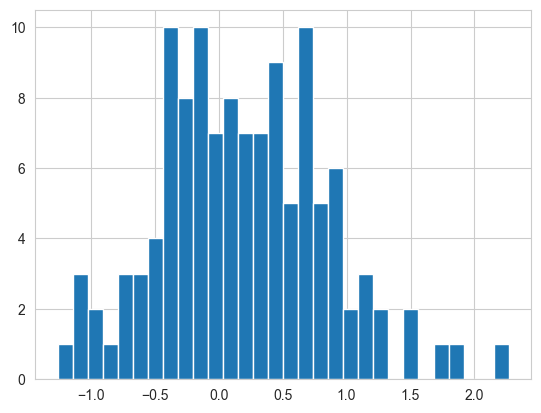

In [94]:
idx = "2105"

plt.hist(np.array(df_country_subfield_norm_world_log[idx]), bins=30)
plt.show()

In [19]:
uf.get_country_info("UZ")

,name,region,sub-region,code
238,Uzbekistan,Asia,Central Asia,UZ


In [21]:
px.histogram(df_country_subfield_norm_world_log["2207"].to_frame("share"), x="share", nbins=100)

In [82]:
uf.plotly_heatmap(
    # df_country_subfield_norm_world,
    # y_labels=df_country_subfield_norm_world.index.astype(str).to_list(),
    df_country_subfield_norm_world.loc[uf.top_n_countries_by_articles(20)],
    y_labels=uf.top_n_countries_by_articles(20),
    x_labels=df_country_subfield_norm_world.columns.astype(str).to_list(),
    y_type="country",
    x_type="subfield",
    y_name="Country",
    x_name="Subfield",
    title="Interest measure (Representation vs The world)",
    line_height=40,
    z_min=0, z_max=2
)

In [81]:
uf.plotly_heatmap(
    # df_country_subfield_norm_world_log,
    # y_labels=df_country_subfield_norm_world.index.astype(str).to_list(),
    df_country_subfield_norm_world_log.loc[uf.top_n_countries_by_articles(20)],
    y_labels=uf.top_n_countries_by_articles(20),
    x_labels=df_country_subfield_norm_world.columns.astype(str).to_list(),
    y_type="country",
    x_type="subfield",
    y_name="Country",
    x_name="Subfield",
    title="Interest measure - log (Representation vs The world)",
    line_height=40,
    z_min=-2, z_max=2
)

In [80]:
uf.plotly_heatmap(
    # df_country_subfield_norm_world_norm,
    # y_labels=df_country_subfield_norm_world.index.astype(str).to_list(),
    df_country_subfield_norm_world_norm.loc[uf.top_n_countries_by_articles(20)],
    y_labels=uf.top_n_countries_by_articles(20),
    x_labels=df_country_subfield_norm_world.columns.astype(str).to_list(),
    y_type="country",
    x_type="subfield",
    y_name="Country",
    x_name="Subfield",
    title="Interest measure normalised by country (Representation vs The world)",
    line_height=40,
    z_min=0, z_max=0.01
)

In [ ]:
fig = px.line()

In [20]:
uf.get_subfield_info(2405)

,subfield_id,subfield_name,field_name,domain_name
295,2405,Parasitology,Immunology and Microbiology,Life Sciences
